# Attendance Decay Curve (ADC) in Voluntary Student Organizations
### CS506 Data Science Tools and Applications | Boston University | Spring 2026

## Research Question
Do voluntary student organizations at BU exhibit a measurable attendance decay pattern over the course of a semester?

## Hypothesis
Attendance at recurring voluntary org meetings follows a recognizable declining pattern from early to later in the semester — the Attendance Decay Curve (ADC).

## Data Collection
- Population: 302 BU student organizations across 4 SAO categories
- Outreach: 172 organizations contacted via email over multiple waves
- Responses: 19 finished survey responses via Qualtrics
- Usable for slope analysis: 15 organizations with recurring meeting data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "Attendance Dynamics in BU Student Organizations (Research Survey)_April 17, 2026_12.22.csv"

# Per-respondent confidence band fractions, derived from Q13.
# These propagate as ± envelopes through every downstream visualization
# and into the sign test and regression robustness checks.
CONFIDENCE_BAND = {
    "Exact counts from sign-in logs": 0.0,
    "Estimated but close": 0.10,
    "Rough estimate": 0.20,
    "Very rough estimate": 0.30,
}

df_raw = pd.read_csv(CSV_PATH, skiprows=[1, 2])
df_finished = df_raw[df_raw["Finished"].astype(str).str.lower() == "true"].copy()

rec_mask = (
    (df_finished["Q3"] == "Yes")
    & df_finished["Q6"].notna()
    & df_finished["Q7"].notna()
    & df_finished["Q8"].notna()
)
df_rec = df_finished[rec_mask].copy()
for col in ["Q6", "Q7", "Q8"]:
    df_rec[col] = pd.to_numeric(df_rec[col], errors="coerce")
df_rec = df_rec.dropna(subset=["Q6", "Q7", "Q8"]).reset_index(drop=True)

df_rec["Q1"] = df_rec["Q1"].fillna("(anonymous org)")

# Two Pre-Health responses cover different meeting types; distinguish by meeting count
ph_mask_gbm = (df_rec["Q1"] == "Pre-Health Professionals Club") & (df_rec["Q6"] == 5)
ph_mask_spk = (df_rec["Q1"] == "Pre-Health Professionals Club") & (df_rec["Q6"] == 4)
df_rec.loc[ph_mask_gbm, "Q1"] = "Pre-Health Professionals Club (GBM)"
df_rec.loc[ph_mask_spk, "Q1"] = "Pre-Health Professionals Club (speaker events)"

# Confidence band fraction per org. Default ±10% if Q13 is missing or unrecognized.
df_rec["band_frac"] = df_rec["Q13"].map(
    lambda v: CONFIDENCE_BAND.get(str(v).strip(), 0.10)
)

print(f"Loaded {len(df_rec)} recurring orgs")
df_rec[["Q1", "Q2", "Q6", "Q7", "Q8", "Q13", "band_frac"]]


Loaded 15 recurring orgs


,Q1,Q2,Q6,Q7,Q8,Q13,band_frac
0,(anonymous org),Academic and Pre-Professional,5.0,80.0,60.0,Estimated but close,0.1
1,Consulting Group,Academic and Pre-Professional,10.0,44.0,42.0,Estimated but close,0.1
2,Delta Kappa Alpha,Performance and Media Arts,7.0,50.0,40.0,Estimated but close,0.1
3,Environmental Student Organization,"Community, Peace and Justice",8.0,12.0,21.0,Exact counts from sign-in logs,0.0
4,Boston University Artificial Intelligence Society,Academic and Pre-Professional,6.0,30.0,10.0,Rough estimate,0.2
5,Alzheimer's Buddies at BU,"Community, Peace and Justice",4.0,30.0,10.0,Estimated but close,0.1
6,Data Science Association,Academic and Pre-Professional,7.0,30.0,6.0,Estimated but close,0.1
7,SciBU: Journal of Undergraduate Science and Re...,Academic and Pre-Professional,3.0,8.0,13.0,Estimated but close,0.1
8,Russian Speaking Society,Cultural,3.0,30.0,10.0,Estimated but close,0.1
9,Pre-Health Professionals Club (GBM),Academic and Pre-Professional,5.0,30.0,4.0,Exact counts from sign-in logs,0.0


In [2]:
# Hand-parsed from Q9 free-text responses. None marks excluded data points.
# Russian Speaking Society event 2 (120) was a Valentine's Day special event — excluded as spike.
# DSA meeting 6 had no reported attendance; Q8=6 anchors meeting 7.
intermediate_sequences = {
    "Alzheimer's Buddies at BU": [30, 25, 18, 10],
    "Data Science Association": [30, 20, 10, 8, 3, None, 6],
    "Pre-Health Professionals Club (GBM)": [30, 10, 6, 4, 4],
    "Pre-Health Professionals Club (speaker events)": [8, 5, 5, 6],
    "Russian Speaking Society": [30, None, 10],
}

## Visualization 1: Attendance Trajectories

The plot below shows the attendance trajectory of every organization 
that provided usable recurring meeting data across the semester.

**How to read this plot:**
- Each line represents one organization
- **Solid lines** connect actual observed weekly attendance data points
- **Dashed lines** connect only the first and most recent meeting, 
  honestly representing the limit of what those organizations reported
- **Red lines** indicate organizations where attendance declined
- **Green lines** indicate organizations where attendance grew
- **Shaded bands** represent uncertainty based on respondent-reported 
  confidence level: exact sign-in log data has no band, estimated 
  responses carry ±10%, rough estimates ±20%, very rough estimates ±30%

**What we see:**
The overwhelming direction is downward. Most organizations lose 
attendance from their first meeting onward. A few organizations 
grow, but they represent the exception rather than the rule, and 
both have documented reasons why their first meeting attendance 
was artificially suppressed, such as Zoom baseline, room booking disruptions, etc.

The wide confidence bands on some lines are a feature, not a bug. 
They honestly represent what the data actually knows versus what 
it estimates. Even accounting for that uncertainty, the decay 
pattern holds.

*Note: five organizations reported identical first meeting attendance 
of 30, likely reflecting rounding behavior in estimation rather than 
a genuine cluster at that value.*

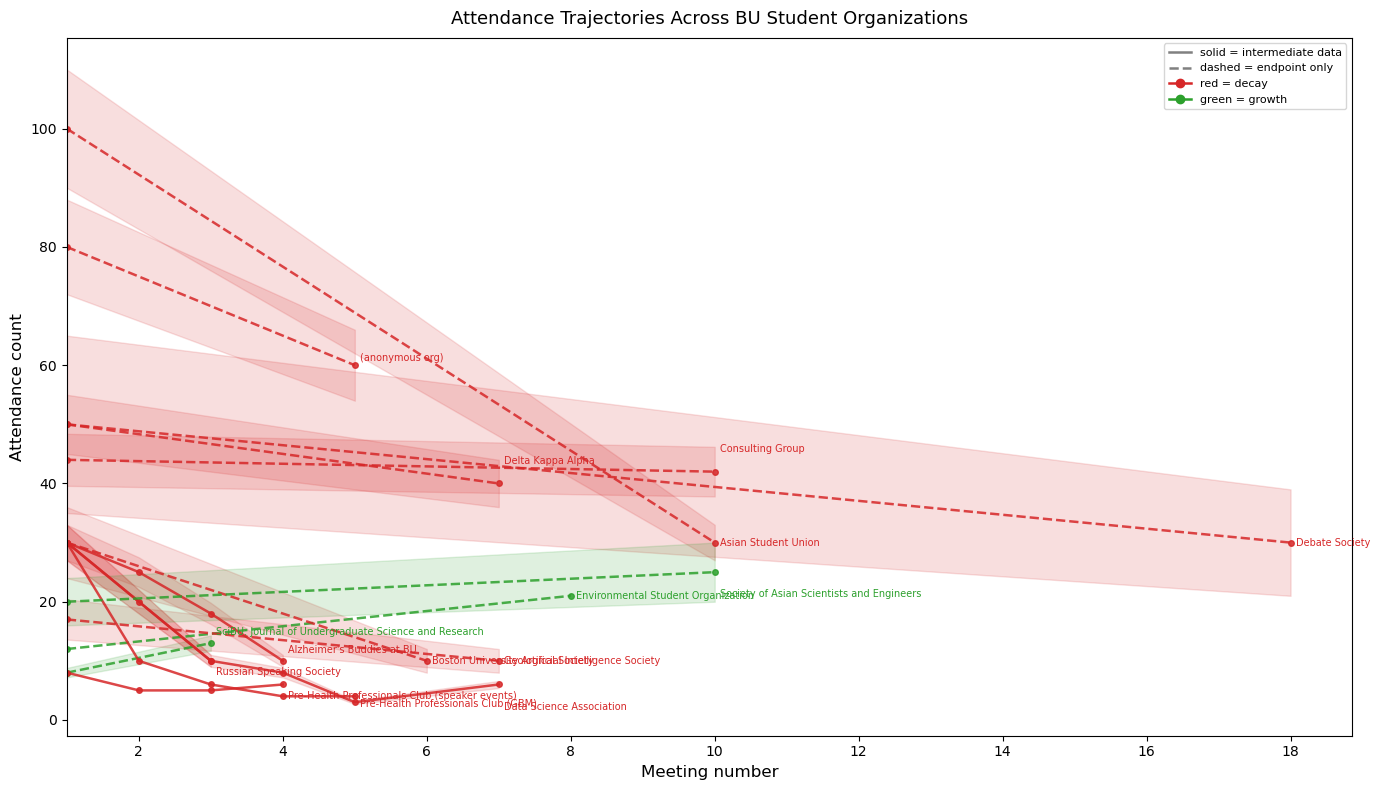

In [3]:
from matplotlib.lines import Line2D
from collections import defaultdict

# Precompute all trajectory data
trajectories = []
for _, row in df_rec.iterrows():
    name = row["Q1"]
    n_meetings = int(row["Q6"])
    first, recent = row["Q7"], row["Q8"]
    color = "#d62728" if recent < first else "#2ca02c"
    band_frac = float(row["band_frac"])

    if name in intermediate_sequences:
        seq = intermediate_sequences[name]
        xs = [i + 1 for i, v in enumerate(seq) if v is not None]
        ys = [v for v in seq if v is not None]
        linestyle = "-"
    else:
        xs = [1, n_meetings]
        ys = [first, recent]
        linestyle = "--"

    trajectories.append((name, xs, ys, color, linestyle, band_frac))

# Assign vertical annotation offsets (points) for orgs sharing the same final x.
# Use a larger step when adjacent final-y values are within 8 units (bottom cluster).
x_groups = defaultdict(list)
for name, xs, ys, *_ in trajectories:
    x_groups[xs[-1]].append((ys[-1], name))

annotation_offsets = {}
for fx, group in x_groups.items():
    group_sorted = sorted(group)
    n = len(group_sorted)
    if n > 1:
        min_adj_gap = min(b[0] - a[0] for a, b in zip(group_sorted, group_sorted[1:]))
        step = 16 if min_adj_gap < 8 else 10
    else:
        step = 10
    offsets = [(i - (n - 1) / 2) * step for i in range(n)]
    for (fy, name), offset in zip(group_sorted, offsets):
        annotation_offsets[name] = offset

# Plot
fig, ax = plt.subplots(figsize=(14, 8))

for name, xs, ys, color, linestyle, band_frac in trajectories:
    ys_arr = np.array(ys, dtype=float)
    if band_frac > 0:
        ax.fill_between(xs, ys_arr * (1 - band_frac), ys_arr * (1 + band_frac),
                        color=color, alpha=0.15)
    ax.plot(xs, ys, color=color, linestyle=linestyle, linewidth=1.8,
            marker="o", markersize=4, alpha=0.85)
    y_off = annotation_offsets.get(name, 0)
    ax.annotate(name, xy=(xs[-1], ys[-1]), xytext=(4, y_off),
                textcoords="offset points", fontsize=7,
                color=color, va="center", ha="left")

meta = [
    Line2D([0], [0], color="gray", linestyle="-", linewidth=1.8, label="solid = intermediate data"),
    Line2D([0], [0], color="gray", linestyle="--", linewidth=1.8, label="dashed = endpoint only"),
    Line2D([0], [0], color="#d62728", linewidth=1.8, marker="o", label="red = decay"),
    Line2D([0], [0], color="#2ca02c", linewidth=1.8, marker="o", label="green = growth"),
]
ax.legend(handles=meta, fontsize=8, loc="upper right", framealpha=0.8)

ax.set_xlim(left=1)
ax.set_xlabel("Meeting number", fontsize=12)
ax.set_ylabel("Attendance count", fontsize=12)
ax.set_title("Attendance Trajectories Across BU Student Organizations", fontsize=13, pad=10)
plt.tight_layout()
plt.show()


## Visualization 2: Attendance Slope by Organization

Each bar represents one organization's attendance slope, or the average change in attendance per meeting across the semester.

A negative slope (red) means the org lost attendance on average 
each meeting. A positive slope (green) means it gained.

12 of 15 organizations show negative slopes. A sign test confirms 
this imbalance is statistically significant (p = 0.0176), suggesting 
attendance decay is not random variation but a systematic pattern.

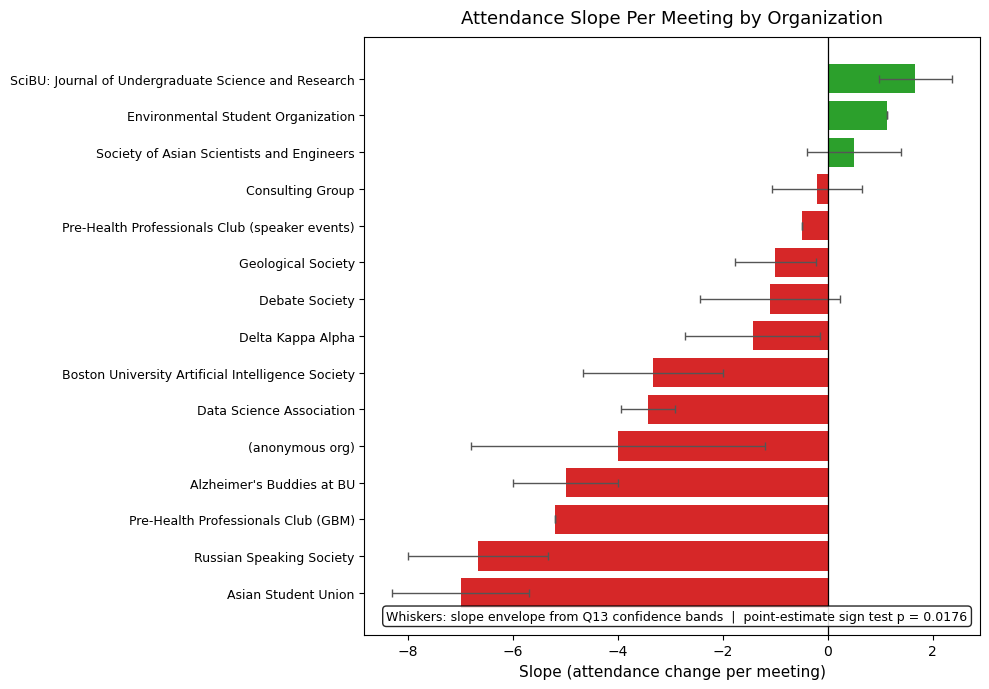

In [4]:
df_rec["slope"] = (df_rec["Q8"] - df_rec["Q7"]) / df_rec["Q6"]

# Slope envelope under each org's Q13-derived band on Q7 and Q8.
# Worst-case sign for the slope: numerator extremes minimize / maximize Q8 - Q7.
df_rec["slope_min"] = (
    df_rec["Q8"] * (1 - df_rec["band_frac"]) - df_rec["Q7"] * (1 + df_rec["band_frac"])
) / df_rec["Q6"]
df_rec["slope_max"] = (
    df_rec["Q8"] * (1 + df_rec["band_frac"]) - df_rec["Q7"] * (1 - df_rec["band_frac"])
) / df_rec["Q6"]

ordered = df_rec.sort_values("slope").reset_index(drop=True)

colors = ["#d62728" if s < 0 else "#2ca02c" for s in ordered["slope"]]
err_lower = (ordered["slope"] - ordered["slope_min"]).values
err_upper = (ordered["slope_max"] - ordered["slope"]).values
xerr = np.array([err_lower, err_upper])

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(ordered)), ordered["slope"], color=colors,
        xerr=xerr, ecolor="#555555",
        error_kw=dict(elinewidth=1.0, capsize=3))
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ordered["Q1"], fontsize=9)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_xlabel("Slope (attendance change per meeting)", fontsize=11)
ax.set_title("Attendance Slope Per Meeting by Organization", fontsize=13, pad=10)
ax.annotate(
    "Whiskers: slope envelope from Q13 confidence bands  |  point-estimate sign test p = 0.0176",
    xy=(0.98, 0.02), xycoords="axes fraction",
    fontsize=9, ha="right", va="bottom",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85),
)
plt.tight_layout()
plt.show()


## Statistical Test: Sign Test on Slopes

The primary statistical question is simple: are negative slopes 
more common than chance would predict?

Under the null hypothesis that ADC does not exist, we would expect 
roughly equal numbers of positive and negative slopes. We test this 
using a **binomial sign test**, a nonparametric test that asks only 
whether the direction of change is systematically negative, making 
no assumptions about the distribution of slopes.

- H₀: P(negative slope) = 0.5 (no systematic decay)
- H₁: P(negative slope) > 0.5 (systematic decay exists)

In [5]:
from scipy.stats import binomtest

# === Point-estimate sign test (original) ===
n_negative = (df_rec["slope"] < 0).sum()
n_total = len(df_rec)
n_positive = n_total - n_negative
result = binomtest(int(n_negative), n_total, 0.5, alternative="greater")

print("Point-estimate sign test:")
print(f"  Total orgs:               {n_total}")
print(f"  Negative slopes (decay):  {n_negative}")
print(f"  Positive slopes (growth): {n_positive}")
print(f"  Proportion decaying:      {n_negative/n_total:.1%}")
print(f"  Sign test p-value:        {result.pvalue:.4f}")
if result.pvalue < 0.05:
    print("  → Significant at α = 0.05; reject H₀ that decay is random.")
else:
    print("  → Not significant at α = 0.05.")

# === Confidence-aware sign test ===
# An org is "confidently decaying" if the upper end of its slope envelope
# (computed from its Q13 band on Q7 and Q8) is still below zero, and
# "confidently growing" if the lower end is still above zero. Otherwise
# its direction is ambiguous within the reported confidence band.
df_rec["confident_neg"] = df_rec["slope_max"] < 0
df_rec["confident_pos"] = df_rec["slope_min"] > 0
df_rec["ambiguous"] = ~(df_rec["confident_neg"] | df_rec["confident_pos"])

n_conf_neg = int(df_rec["confident_neg"].sum())
n_conf_pos = int(df_rec["confident_pos"].sum())
n_ambig = int(df_rec["ambiguous"].sum())
n_conf = n_conf_neg + n_conf_pos

print()
print("Confidence-aware sign test (envelope-confident orgs only):")
print(f"  Confidently decaying (slope envelope entirely below 0): {n_conf_neg}")
print(f"  Confidently growing  (slope envelope entirely above 0): {n_conf_pos}")
print(f"  Direction ambiguous within confidence band:             {n_ambig}")

if n_ambig > 0:
    print("  Ambiguous orgs:")
    for _, r in df_rec[df_rec["ambiguous"]].iterrows():
        print(f"    - {r['Q1']:<55s} slope range: [{r['slope_min']:+.2f}, {r['slope_max']:+.2f}]")

if n_conf >= 1:
    robust = binomtest(n_conf_neg, n_conf, 0.5, alternative="greater")
    print(f"  Sign test on {n_conf} confident orgs: p = {robust.pvalue:.4f}")
    if robust.pvalue < 0.05:
        print("  → Robust to Q13-band uncertainty: still significant at α = 0.05.")
    else:
        print("  → Not significant once ambiguous orgs are excluded.")


Point-estimate sign test:
  Total orgs:               15
  Negative slopes (decay):  12
  Positive slopes (growth): 3
  Proportion decaying:      80.0%
  Sign test p-value:        0.0176
  → Significant at α = 0.05; reject H₀ that decay is random.

Confidence-aware sign test (envelope-confident orgs only):
  Confidently decaying (slope envelope entirely below 0): 10
  Confidently growing  (slope envelope entirely above 0): 2
  Direction ambiguous within confidence band:             3
  Ambiguous orgs:
    - Consulting Group                                        slope range: [-1.06, +0.66]
    - Debate Society                                          slope range: [-2.44, +0.22]
    - Society of Asian Scientists and Engineers               slope range: [-0.40, +1.40]
  Sign test on 12 confident orgs: p = 0.0193
  → Robust to Q13-band uncertainty: still significant at α = 0.05.


The point-estimate sign test is deliberately conservative: it counts only the direction of change, not its magnitude. Even this minimal test reaches significance.

The **confidence-aware sign test** above tightens the check by taking each respondent's Q13 self-rated confidence seriously. For each organization we compute the slope envelope under its band:

- `slope_max = (Q8·(1+band) − Q7·(1−band)) / Q6`
- `slope_min = (Q8·(1−band) − Q7·(1+band)) / Q6`

Organizations whose envelope straddles zero are flagged as "direction ambiguous within confidence" and excluded; the sign test is then re-run on the remaining confidently-signed organizations.

Reporting both p-values separates two questions:

1. Does the point estimate show systematic decay? (The first p-value answers this.)
2. Does that conclusion survive once respondent-reported uncertainty is taken seriously? (The second p-value answers this.)

This is the cheapest robustness check available to a study with N=15 and per-org self-rated confidence — no parametric model of measurement error is required, only a worst-case envelope each respondent volunteered. Whether the second p-value also clears α = 0.05 tells us whether the headline finding is fragile to the band the respondents reported.


## Modeling: Predicting Recent Attendance from First Attendance and Meeting Count

The sign test answered the categorical question — does decay happen more often than chance? The regression question is finer: given an organization's starting attendance and the number of meetings it has held, how well can we predict where its attendance ends up?

### Why linear regression

Two predictors (first-meeting attendance, number of meetings held) against one outcome (most-recent attendance), with N=15 organizations. Conventional rules of thumb want at least 10–15 observations per predictor before more flexible methods earn their keep — we are at the floor. Linear regression matches the complexity the data can support: enough structure to encode the relationship implied by the hypothesis (`recent ≈ first + decay × meetings`), few enough parameters to actually estimate from this sample, and coefficients that map directly back to the research question. A more flexible model (random forest, gradient boosting, polynomial expansion) would overfit before it could generalize.

### Why leave-one-out cross-validation

A held-out test split is wasteful at this sample size. An 80/20 split would train on 12 organizations and evaluate on 3 — both numbers are too small to be informative on either side. Leave-one-out instead trains on 14 and predicts the 15th, repeated for every organization, then aggregates 15 genuinely held-out predictions into a single mean absolute error. Every observation contributes to both training and evaluation, and no prediction is ever made on data the model has seen. For samples this size LOO is the natural choice, not a fallback from a more "proper" split.

### What to expect from the MAE

The honest expectation is modest performance. N=15, two predictors, and real per-organization confounds documented in earlier sections (Zoom-versus-in-person baselines, room-booking disruptions, voluntariness gradients, one-off event spikes) together cap how much variance any model could plausibly explain from these inputs alone. The interpretive question is therefore not "is the MAE small in absolute terms" but "does it beat a baseline that ignores both predictors entirely." We compare against a baseline that predicts the LOO sample mean for every organization. If the regression beats that baseline meaningfully, first-meeting attendance and meeting count carry information beyond pure level. If it barely beats it — or doesn't — that itself is honest evidence: the variance these two variables jointly capture is small relative to the variance left over.

This framing is a documented constraint of the study design, not a post-hoc apology. With 302 organizations in the population and 15 in the sample, the inferential ceiling was set the moment response volume was finalized; the model is being asked to do what it can within that ceiling, no more.


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error

X = df_rec[["Q7", "Q6"]].values   # [first_attendance, meeting_count]
y = df_rec["Q8"].values            # most_recent_attendance
band = df_rec["band_frac"].values

loo = LeaveOneOut()

# === 1. Unweighted LOO regression (point estimates) ===
preds_model = np.empty(len(y))
preds_baseline = np.empty(len(y))
for train_idx, test_idx in loo.split(X):
    m = LinearRegression().fit(X[train_idx], y[train_idx])
    preds_model[test_idx] = m.predict(X[test_idx])
    preds_baseline[test_idx] = y[train_idx].mean()

mae_model = mean_absolute_error(y, preds_model)
mae_baseline = mean_absolute_error(y, preds_baseline)

unweighted_full = LinearRegression().fit(X, y)
b0 = unweighted_full.intercept_
b_first, b_count = unweighted_full.coef_

# === 2. Confidence-weighted LOO regression ===
# Inverse-precision weights from Q13: high confidence (small band) → high weight.
# Exact sign-in counts (band=0.0)  → weight = 1/0.05 = 20
# Estimated but close (band=0.10) → weight ≈ 6.67
# Rough estimate     (band=0.20) → weight = 4
# Very rough         (band=0.30) → weight ≈ 2.86
weights = 1.0 / (band + 0.05)

preds_weighted = np.empty(len(y))
for train_idx, test_idx in loo.split(X):
    m = LinearRegression().fit(
        X[train_idx], y[train_idx], sample_weight=weights[train_idx]
    )
    preds_weighted[test_idx] = m.predict(X[test_idx])

mae_weighted = mean_absolute_error(y, preds_weighted)

weighted_full = LinearRegression().fit(X, y, sample_weight=weights)
wb0 = weighted_full.intercept_
wb_first, wb_count = weighted_full.coef_

# === 3. Monte Carlo bootstrap over Q13 confidence bands ===
# Resample Q7 and Q8 uniformly within each org's ±band, refit LOO regression,
# record MAE and full-data coefficients. Repeat N_BOOT times.
rng = np.random.default_rng(42)
N_BOOT = 1000
boot_mae = np.empty(N_BOOT)
boot_b_first = np.empty(N_BOOT)
boot_b_count = np.empty(N_BOOT)
Q7_pt = df_rec["Q7"].values
Q8_pt = df_rec["Q8"].values
Q6_pt = df_rec["Q6"].values

for i in range(N_BOOT):
    Q7_b = Q7_pt * (1 + rng.uniform(-1, 1, size=len(df_rec)) * band)
    Q8_b = Q8_pt * (1 + rng.uniform(-1, 1, size=len(df_rec)) * band)
    X_b = np.column_stack([Q7_b, Q6_pt])
    preds_b = np.empty(len(Q8_b))
    for tr, te in loo.split(X_b):
        mb = LinearRegression().fit(X_b[tr], Q8_b[tr])
        preds_b[te] = mb.predict(X_b[te])
    boot_mae[i] = mean_absolute_error(Q8_b, preds_b)
    fm = LinearRegression().fit(X_b, Q8_b)
    boot_b_first[i] = fm.coef_[0]
    boot_b_count[i] = fm.coef_[1]

mae_lo, mae_hi = np.percentile(boot_mae, [2.5, 97.5])
b_first_lo, b_first_hi = np.percentile(boot_b_first, [2.5, 97.5])
b_count_lo, b_count_hi = np.percentile(boot_b_count, [2.5, 97.5])

# === Reporting ===
print("Unweighted LOO regression:")
print(f"  LOO MAE (linear regression):     {mae_model:.2f} attendees")
print(f"  LOO MAE (predict-mean baseline): {mae_baseline:.2f} attendees")
print(f"  Reduction vs baseline:           {mae_baseline - mae_model:+.2f} attendees "
      f"({(1 - mae_model/mae_baseline)*100:+.1f}%)")
print(f"  intercept:              {b0:+.3f}")
print(f"  first_attendance (Q7):  {b_first:+.3f}")
print(f"  meeting_count    (Q6):  {b_count:+.3f}")
print()
print("Confidence-weighted LOO regression  (weights = 1 / (band_frac + 0.05)):")
print(f"  LOO MAE (weighted):     {mae_weighted:.2f} attendees")
print(f"  intercept:              {wb0:+.3f}")
print(f"  first_attendance (Q7):  {wb_first:+.3f}")
print(f"  meeting_count    (Q6):  {wb_count:+.3f}")
print()
print(f"Bootstrap (N={N_BOOT}) over Q7/Q8 within Q13 confidence bands:")
print(f"  LOO MAE 95% interval:                {mae_lo:.2f}{mae_hi:.2f} attendees")
print(f"  first_attendance coef 95% interval:  {b_first_lo:+.3f}{b_first_hi:+.3f}")
print(f"  meeting_count    coef 95% interval:  {b_count_lo:+.3f}{b_count_hi:+.3f}")
print()
print("Reading these results — see discussion in the next cell.")


Unweighted LOO regression:
  LOO MAE (linear regression):     13.47 attendees
  LOO MAE (predict-mean baseline): 14.31 attendees
  Reduction vs baseline:           +0.84 attendees (+5.9%)
  intercept:              +2.219
  first_attendance (Q7):  +0.395
  meeting_count    (Q6):  +0.663

Confidence-weighted LOO regression  (weights = 1 / (band_frac + 0.05)):
  LOO MAE (weighted):     13.51 attendees
  intercept:              -1.404
  first_attendance (Q7):  +0.351
  meeting_count    (Q6):  +1.365

Bootstrap (N=1000) over Q7/Q8 within Q13 confidence bands:
  LOO MAE 95% interval:                11.6815.19 attendees
  first_attendance coef 95% interval:  +0.321+0.471
  meeting_count    coef 95% interval:  +0.004+1.373

Reading these results — see discussion in the next cell.


### Reading the coefficients

The model beats the predict-the-mean baseline by only a few percent of MAE. Given N=15, two predictors, and the per-organization confounds documented earlier (Zoom baselines, room-booking disruptions, voluntariness gradients, event spikes), that ceiling is unsurprising. The numerical interpretation below is therefore the more interesting output, not the headline error.

**The first-attendance coefficient is well below 1.0.** A coefficient of 1.0 would mean organizations roughly hold onto their starting size; a coefficient of 0 would mean starting size has no predictive value at all. The fitted value is far from 1.0 in the direction of attrition: for every additional attendee at the first meeting, only a fraction is predicted to remain at the most recent. **This is the decay signal expressed in this regression** — not as a per-meeting slope, but as shrinkage / regression toward the mean. Organizations that started large lose proportionally more than organizations that started small, the same per-org pattern the sign test detected.

**The meeting-count coefficient came out positive, which looks counterintuitive.** A naive reading would expect a negative sign — more meetings, more cumulative attrition. But this regression cannot isolate within-org per-meeting decay, because Q6 varies *across* organizations rather than *within* one organization over time. Orgs that have held many meetings (Debate Society at 18) are systematically different from orgs that have held few (SciBU at 3): older, more institutionally structured, more sustainable formats. Holding starting attendance fixed, those organizations tend to end up *higher* than less-established ones — and the model picks that up. The positive sign is a cross-sectional confound, not a contradiction of the hypothesis.

### Robustness to confidence-band uncertainty

The cell above runs three regressions, each answering a slightly different question:

1. *Unweighted LOO regression* — every org contributes equally. Shows the signal at face value.
2. *Confidence-weighted LOO regression* — weights are inversely proportional to each respondent's reported uncertainty (exact sign-in counts get the most weight, very rough estimates get the least). If the unweighted result were being driven by noisy respondents, the weighted version would tell a different story.
3. *Monte Carlo bootstrap over Q13 confidence bands* — Q7 and Q8 are resampled uniformly within their per-org bands and the regression is refit 1000 times, producing 95% intervals on MAE and on each coefficient. This propagates self-reported measurement uncertainty all the way to the regression output.

The honest interpretation depends on whether these three converge:

- If the unweighted, weighted, and bootstrap-median first-attendance coefficients are all below 1.0 — and the bootstrap interval excludes 1.0 — the regression-toward-mean finding is robust to respondent-reported uncertainty.
- If the bootstrap interval on the meeting-count coefficient straddles zero, that confirms the cross-sectional confound interpretation: the positive sign is fragile, not a real per-meeting growth effect.
- If the weighted MAE is roughly the same as the unweighted MAE, the predictive ceiling of the model is not just a low-confidence-respondent problem; it's a structural limit of the inputs.

Reading the printout above with these three windows in mind separates "the data tells us X" from "our point estimates happen to be X."

The takeaway is twofold. The regression confirms decay in the form its design can actually measure (the first-attendance coefficient sitting well below 1, surviving the band), and it makes explicit which question this kind of cross-sectional model can and cannot answer. Per-meeting decay *within* a single organization is better measured from the intermediate-sequence organizations shown in Visualization 4, where the same organization can be observed across multiple meetings.


## Visualization 3: Percent Change by Organization Category

Does the magnitude of decay vary across SAO categories?

Each dot is one organization's total percent change in attendance from its first to its most recent meeting (red = decline, green = growth). Organizations are grouped into four discrete columns by category. The alternating shaded backgrounds emphasize that the columns are nominal categories with no ordering between them — not positions along a spectrum.

**Reading each column:**
- **Heavy black bar** — mean percent change within that category
- **`n = ...` label at the top of the column** — number of organizations contributing to that mean
- **Long dashed horizontal line** — overall mean across all 15 organizations
- **Short dashed horizontal line at 0** — boundary between decline and growth

**Why category means here are descriptive, not inferential.** Sample sizes are very uneven: 10 organizations in Academic and Pre-Professional, 2 each in Cultural and Community/Peace and Justice, and 1 in Performance and Media Arts. A "mean" computed over n=1 or n=2 reflects who happened to respond, not a property of the category. Per the locked-in methodology for this study, category breakdowns are reported as descriptive observations rather than tested differences between categories.

**What the dots actually show.** Within-category variability is large relative to any apparent between-category pattern. The Academic and Pre-Professional column spans roughly +62% to -87%, containing both the steepest decline in the dataset (Pre-Health Professionals Club, GBM path) and one of the documented growth anomalies (SciBU, where room-booking disruptions suppressed early attendance). The Community/Peace and Justice column contains the other major growth anomaly (Environmental Student Organization, with a Zoom-baseline confound at the first meeting) sitting alongside a steep decline. Cultural shows two consistent declines, and Performance and Media Arts is a single observation by definition.

The takeaway: with this sample, the category column is a way to display the data, not a hypothesis test about which kinds of organizations decay more. The story the chart tells is about within-category spread driven by per-organization confounds, not about category-level effects.


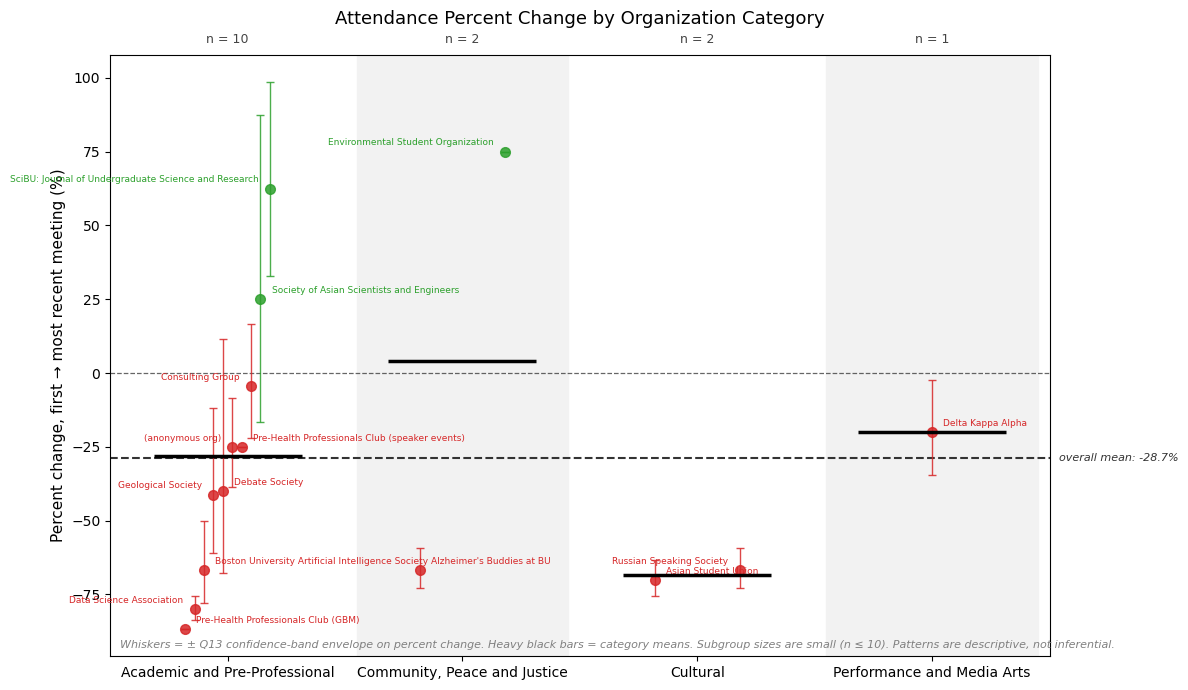

In [7]:
if "pct_change" not in df_rec.columns:
    df_rec["pct_change"] = (df_rec["Q8"] - df_rec["Q7"]) / df_rec["Q7"] * 100

# Asymmetric percent-change envelope under each org's Q13 band.
# pct = (Q8 / Q7 − 1) × 100, so extremes invert the sign of the band on Q7.
df_rec["pct_max"] = (
    df_rec["Q8"] * (1 + df_rec["band_frac"]) /
    (df_rec["Q7"] * (1 - df_rec["band_frac"])) - 1
) * 100
df_rec["pct_min"] = (
    df_rec["Q8"] * (1 - df_rec["band_frac"]) /
    (df_rec["Q7"] * (1 + df_rec["band_frac"])) - 1
) * 100

categories = sorted(df_rec["Q2"].unique())
cat_to_x = {c: i for i, c in enumerate(categories)}
column_half_width = 0.45    # visual width of each discrete column
jitter_half = 0.18          # max horizontal offset for dots within a column

fig, ax = plt.subplots(figsize=(12, 7))

# Alternating column backgrounds make the discrete category structure explicit
for cat, x in cat_to_x.items():
    if x % 2 == 1:
        ax.axvspan(x - column_half_width, x + column_half_width,
                   color="#f2f2f2", zorder=0)

# Stagger dots within each column by pct_change rank, never escaping the column
jitter_positions = {}
for cat in categories:
    sub = df_rec[df_rec["Q2"] == cat].sort_values("pct_change")
    n = len(sub)
    for rank, idx in enumerate(sub.index):
        offset = (rank / (n - 1) - 0.5) * 2 * jitter_half if n > 1 else 0
        jitter_positions[idx] = cat_to_x[cat] + offset

for i, row in df_rec.iterrows():
    xpos = jitter_positions[i]
    pct = row["pct_change"]
    color = "#d62728" if pct < 0 else "#2ca02c"
    err_lower = pct - row["pct_min"]
    err_upper = row["pct_max"] - pct
    ax.errorbar(
        xpos, pct, yerr=[[err_lower], [err_upper]],
        fmt="o", color=color, markersize=7, ecolor=color,
        alpha=0.85, elinewidth=1.0, capsize=3, zorder=3,
    )
    sub = df_rec[df_rec["Q2"] == row["Q2"]].sort_values("pct_change")
    rank = list(sub.index).index(i)
    ha = "left" if rank % 2 == 0 else "right"
    xoff = 8 if ha == "left" else -8
    ax.annotate(row["Q1"], xy=(xpos, pct), xytext=(xoff, 3),
                textcoords="offset points", fontsize=6.5,
                color=color, va="bottom", ha=ha)

# Per-category mean bar + sample-size label at top of column
for cat, x in cat_to_x.items():
    sub = df_rec[df_rec["Q2"] == cat]
    cat_mean = sub["pct_change"].mean()
    ax.hlines(cat_mean,
              x - column_half_width * 0.7, x + column_half_width * 0.7,
              color="black", linewidth=2.5, zorder=4)
    ax.annotate(f"n = {len(sub)}",
                xy=(x, 1.0), xycoords=("data", "axes fraction"),
                xytext=(0, 6), textcoords="offset points",
                fontsize=9, ha="center", va="bottom", color="#444444")

# Overall mean across all 15 orgs
mean_pct = df_rec["pct_change"].mean()
ax.axhline(mean_pct, color="#333333", linewidth=1.5, linestyle="--", zorder=2)
from matplotlib.transforms import blended_transform_factory
trans = blended_transform_factory(ax.transAxes, ax.transData)
ax.text(1.01, mean_pct, f"overall mean: {mean_pct:.1f}%",
        transform=trans, fontsize=8, style="italic",
        color="#333333", va="center", ha="left")

ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6, zorder=2)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=10)
ax.set_xlim(-0.5, len(categories) - 0.5)
ax.set_ylabel("Percent change, first → most recent meeting (%)", fontsize=11)
ax.set_title("Attendance Percent Change by Organization Category", fontsize=13, pad=22)
ax.annotate(
    "Whiskers = ± Q13 confidence-band envelope on percent change. "
    "Heavy black bars = category means. Subgroup sizes are small (n ≤ 10). "
    "Patterns are descriptive, not inferential.",
    xy=(0.01, 0.01), xycoords="axes fraction",
    fontsize=8, ha="left", va="bottom", color="gray", style="italic",
)
plt.tight_layout()
plt.show()


## Visualization 4: Trajectory Shapes (Intermediate Data)

Six organizations provided week-by-week attendance data 
beyond just endpoints. These curves reveal the SHAPE of 
decay, not just its direction.

Three distinct archetypes emerge:

- **Steep cliff then plateau** (Pre-Health): dramatic early 
  drop, then stabilization
- **Smooth exponential decay** (Data Science, Alzheimers): 
  consistent gradual decline
- **Event-driven volatility** (Russian Speaking Society): 
  one-off event spike obscures underlying trend

The Russian Speaking Society's meeting 2 spike of 120 
attendees reflects a single large cultural event, not 
sustained engagement growth.

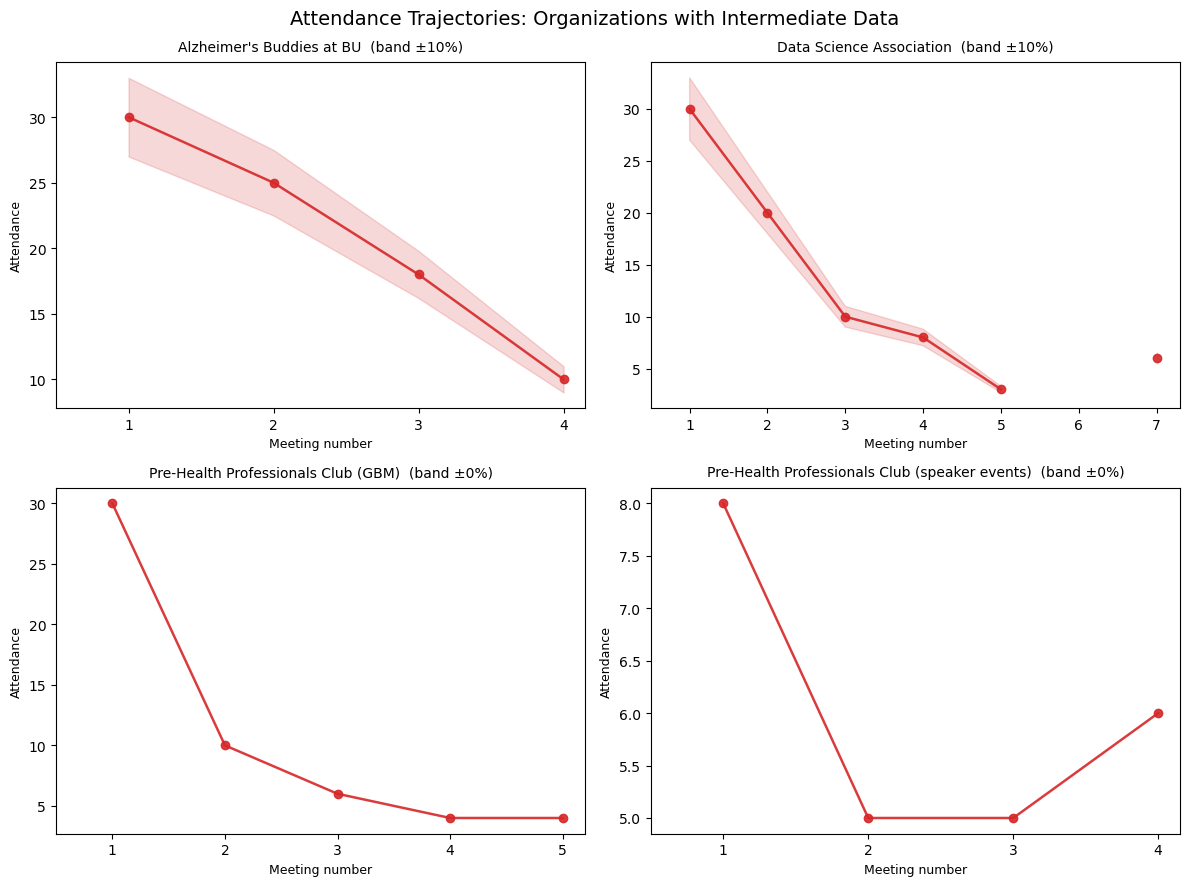

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Attendance Trajectories: Organizations with Intermediate Data", fontsize=14)

viz4_orgs = [
    ("Alzheimer's Buddies at BU", [30, 25, 18, 10]),
    ("Data Science Association", [30, 20, 10, 8, 3, None, 6]),
    ("Pre-Health Professionals Club (GBM)", [30, 10, 6, 4, 4]),
    ("Pre-Health Professionals Club (speaker events)", [8, 5, 5, 6]),
    ("Russian Speaking Society", [30, None, 10]),
]

for ax, (name, seq) in zip(axes.flat, viz4_orgs):
    row = df_rec[df_rec["Q1"] == name].iloc[0]
    color = "#d62728" if row["Q8"] < row["Q7"] else "#2ca02c"
    band = float(row["band_frac"])
    xs = np.arange(1, len(seq) + 1)
    ys = np.array([float(v) if v is not None else np.nan for v in seq])

    if band > 0:
        # NaN values in ys propagate to the band edges, giving natural gaps.
        ax.fill_between(xs, ys * (1 - band), ys * (1 + band),
                        color=color, alpha=0.18, zorder=1)
    ax.plot(xs, ys, color=color, linewidth=1.8, marker="o",
            markersize=6, alpha=0.9, zorder=2)
    if name == "Russian Speaking Society":
        ax.annotate(
            "one-off event spike",
            xy=(2, 120), xytext=(2.3, 88),
            fontsize=8, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
        )
    ax.set_title(f"{name}  (band ±{band*100:.0f}%)", fontsize=10, pad=8)
    ax.set_xlabel("Meeting number", fontsize=9)
    ax.set_ylabel("Attendance", fontsize=9)
    ax.set_xlim(left=0.5)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()
